# SI Demo — Descriptive Analytics
**Domain:** Amman Rides (fictional ride-sharing service)  
**Dataset:** `si_demo/trips.csv` — 1,500 trips, 9 columns



| Step | What you demonstrate | Key teaching point |
|------|----------------------|--------------------|
| 1 | Data inspection | Always profile before plotting |
| 2 | Distribution analysis | Shape matters — right skew → use median |
| 3 | Correlation analysis | Only numeric cols; correlation ≠ causation |
| 4 | Hypothesis testing | t-test to confirm what the chart suggests |

---
## Imports & Setup

In [18]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

%matplotlib inline

os.makedirs("output", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (9, 5)

---
## Step 1 — Data Inspection



In [19]:
df = pd.read_csv("trips.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 1500 rows x 9 columns


In [20]:
# Column data types
df.dtypes

trip_id                  int64
date                       str
time_of_day                str
pickup_neighborhood        str
distance_km            float64
fare_jod               float64
driver_rating          float64
payment_type               str
is_surge                  bool
dtype: object

In [21]:
# Summary statistics for all numeric columns
print(df.describe().round(3))
#print("Skewness (fare_jod):", df["fare_jod"].skew())

        trip_id  distance_km  fare_jod  driver_rating
count  1500.000     1500.000  1500.000       1500.000
mean    750.500        9.315     4.211          4.195
std     433.157        8.307     3.402          0.402
min       1.000        1.000     0.500          2.500
25%     375.750        3.358     1.820          3.900
50%     750.500        6.760     3.207          4.200
75%    1125.250       12.852     5.436          4.500
max    1500.000       56.500    27.024          5.000


In [22]:
# Missing value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")
# No missing values in this demo dataset — good starting point.

Missing values per column:
trip_id                0
date                   0
time_of_day            0
pickup_neighborhood    0
distance_km            0
fare_jod               0
driver_rating          0
payment_type           0
is_surge               0
dtype: int64

Total missing cells: 0


In [23]:
# Unique values — categorical columns
for col in ["time_of_day", "pickup_neighborhood", "payment_type"]:
    vals = sorted([v for v in df[col].unique() if pd.notna(v)])
    print(f"{col}: {vals}")

time_of_day: ['Afternoon', 'Evening', 'Morning', 'Night']
pickup_neighborhood: ['7th Circle', 'Abdoun', 'Jabal Amman', 'Khalda', 'Madina Munawarh', 'Shmeisani', 'Sweifieh', 'Zarqa']
payment_type: ['Card', 'Cash', 'Wallet']


---
## Step 2 — Distribution Analysis



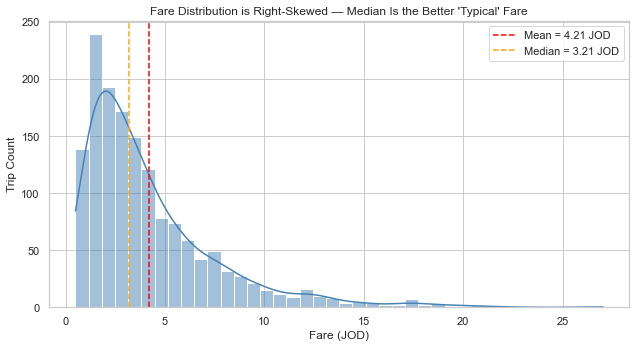

In [24]:
# Fare distribution — right-skewed, annotated with mean and median lines
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(df["fare_jod"], bins=40, kde=True, ax=ax, color="steelblue")

mean_fare   = df["fare_jod"].mean()
median_fare = df["fare_jod"].median()

ax.axvline(mean_fare,   color="red",    linestyle="--", label=f"Mean = {mean_fare:.2f} JOD")
ax.axvline(median_fare, color="orange", linestyle="--", label=f"Median = {median_fare:.2f} JOD")
ax.set_title("Fare Distribution is Right-Skewed — Median Is the Better 'Typical' Fare")
ax.set_xlabel("Fare (JOD)")
ax.set_ylabel("Trip Count")
ax.legend()
fig.tight_layout()
fig.savefig("output/dist_fare.png", dpi=120)
plt.show()

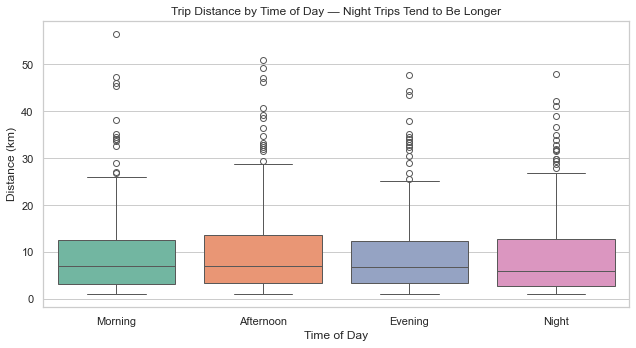

In [25]:
# Trip distance by time of day — box plot
fig, ax = plt.subplots(figsize=FIGSIZE)
time_order = ["Morning", "Afternoon", "Evening", "Night"]
sns.boxplot(data=df, x="time_of_day", y="distance_km",
            order=time_order, ax=ax, palette="Set2")
ax.set_title("Trip Distance by Time of Day — Night Trips Tend to Be Longer")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Distance (km)")
fig.tight_layout()
fig.savefig("output/boxplot_distance_by_time.png", dpi=120)
plt.show()

---
## Step 3 — Correlation Analysis



In [26]:
# Correlation matrix — numeric columns only
numeric_cols = ["distance_km", "fare_jod", "driver_rating"]
corr = df[numeric_cols].corr()
corr.round(3)

,distance_km,fare_jod,driver_rating
distance_km,1.000,0.939,0.028
fare_jod,0.939,1.000,0.026
driver_rating,0.028,0.026,1.000


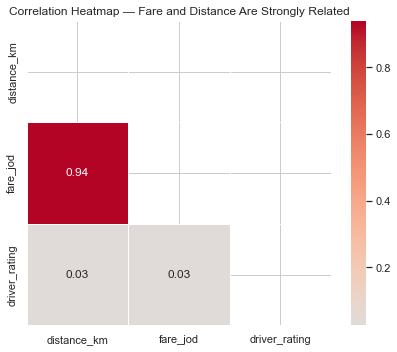

In [27]:
# Correlation heatmap — lower triangle only
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Correlation Heatmap — Fare and Distance Are Strongly Related")
fig.tight_layout()
fig.savefig("output/correlation_heatmap.png", dpi=120)
plt.show()

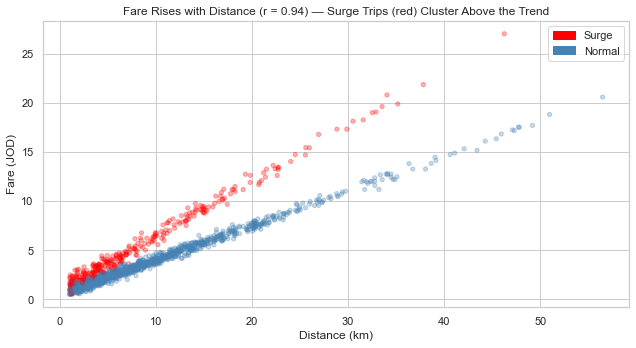


--- Narration point ---
Notice driver_rating has near-zero correlation with fare.
That is a MEANINGLESS correlation — knowing the rating tells us
almost nothing about how much a trip costs.


In [28]:
# Scatter: distance vs fare, coloured by surge status
r = corr.loc["distance_km", "fare_jod"]

fig, ax = plt.subplots(figsize=FIGSIZE)
colors = df["is_surge"].map({True: "red", False: "steelblue"})
ax.scatter(df["distance_km"], df["fare_jod"],
           c=colors, alpha=0.3, s=18)
ax.set_title(f"Fare Rises with Distance (r = {r:.2f}) — Surge Trips (red) Cluster Above the Trend")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Fare (JOD)")
ax.legend(handles=[Patch(color="red",      label="Surge"),
                   Patch(color="steelblue", label="Normal")])
fig.tight_layout()
fig.savefig("output/scatter_distance_vs_fare.png", dpi=120)
plt.show()

print("\n--- Narration point ---")
print("Notice driver_rating has near-zero correlation with fare.")
print("That is a MEANINGLESS correlation — knowing the rating tells us")
print("almost nothing about how much a trip costs.")

---
## Step 4 — Hypothesis Testing: Surge vs Non-Surge Fare

### Hypotheses
- **H₀:** Mean fare (surge trips) = Mean fare (non-surge trips)
- **H₁:** Surge trips have a **higher** average fare *(one-tailed)*



In [29]:
alpha = 0.05

fare_surge  = df.loc[df["is_surge"] == True,  "fare_jod"]
fare_normal = df.loc[df["is_surge"] == False, "fare_jod"]

t_stat, p_two = stats.ttest_ind(fare_surge, fare_normal, equal_var=False)
p_one = p_two / 2  # one-tailed

print(f"Surge trips    : n={len(fare_surge)}, mean fare = {fare_surge.mean():.3f} JOD")
print(f"Non-surge trips: n={len(fare_normal)}, mean fare = {fare_normal.mean():.3f} JOD")
print(f"t-statistic    : {t_stat:.4f}")
print(f"p-value (one-tailed): {p_one:.6f}")

if p_one < alpha and t_stat > 0:
    print(f"\nResult: REJECT H0 (p={p_one:.6f} < {alpha})")
    print("Surge trips have a statistically significantly higher average fare.")
    print(f"The chance of seeing this fare gap by random luck is less than {p_one*100:.4f}%.")
else:
    print(f"\nResult: FAIL TO REJECT H0 (p={p_one:.6f} >= {alpha})")

Surge trips    : n=305, mean fare = 5.790 JOD
Non-surge trips: n=1195, mean fare = 3.808 JOD
t-statistic    : 7.4307
p-value (one-tailed): 0.000000

Result: REJECT H0 (p=0.000000 < 0.05)
Surge trips have a statistically significantly higher average fare.
The chance of seeing this fare gap by random luck is less than 0.0000%.


---
## Summary

| Finding | Detail |
|---------|--------|
| **Fare distribution** | Right-skewed — median is a better central measure than mean |
| **Longest trips** | Night-time trips tend to cover more distance |
| **Strongest correlation** | Distance ↔ Fare (expected: longer trip = higher fare) |
| **Meaningless correlation** | Driver rating ↔ Fare (near-zero r) |
| **Hypothesis test** | Surge pricing significantly raises fares (p ≪ 0.05) |

